<a href="https://colab.research.google.com/github/Soha-Waseem/FlyRank_ML_Week1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Soha-Waseem/FlyRank_ML_Week1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Predicting Content Performance Decline for Search Intelligence

## Abstract

This study asks whether historical search, traffic, engagement, and content signals can help identify content items that are likely to experience a meaningful decline in next-month impressions.

Using the FlyRank internship warehouse, I constructed a monthly content-level dataset and defined decline as a 20% or greater reduction in impressions in the following month.

I compared a constant-probability baseline with leakage-safe Logistic Regression and Random Forest models using a time-based train/test split.

The leakage-safe Random Forest achieved a ROC-AUC of 0.5554 and Average Precision of 0.6386 compared with a ROC-AUC of 0.5000 for the baseline.

The resulting ranking is therefore presented as a directional decision-support tool for prioritizing content review rather than as a causal prediction of future search performance.


# 1. Question

## Research Question

Can historical search, traffic, engagement, and content characteristics help identify content items that are likely to experience a meaningful decline in next-month impressions?

## Decision Supported

The objective is to support content prioritization.

Instead of treating every content item equally, the analysis produces a ranked list of content observations by estimated decline risk. This can help a content team decide which pages should receive earlier review.

The output is intended as directional decision support. It does not establish that any particular content change will cause improved search performance.


# 2. Data

The analysis uses the FlyRank ML Internship warehouse release provided for the internship.

The primary sources used were:

- `fact_content_daily_performance`
- `dim_content`

Daily performance data was aggregated to a monthly content-level representation before modeling.

The available daily performance data covers 2025-01-27 through 2026-06-30, with 520 unique reporting dates, 70 clients, and 427,292 content items.

The resulting monthly modeling table contains 2,748,610 observations covering January 2025 through June 2026.

For the prediction task, an observation is eligible for labeling when a subsequent month is available. This produced 797,753 eligible observations.

A decline was defined as a 20% or greater decrease in impressions in the following month.

The final modeling dataset contained 797,753 observations:

- 319,754 declining observations
- 477,999 non-declining observations
- 40.08% decline rate among eligible observations

Client names, domains, private queries, credentials, and raw exports were excluded from the public analysis.


In [ ]:
import os
import getpass
import duckdb

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        pass

if not HF_TOKEN:
    HF_TOKEN = getpass.getpass("Paste HF token: ")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

TABLES = {
    "dim_clients":
        f"read_parquet('{REL}/dim_clients.parquet')",

    "dim_content":
        f"read_parquet('{REL}/dim_content.parquet')",

    "fact_daily":
        f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",

    "fact_daily_sample":
        f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",

    "fact_query_90d":
        f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(
        f"SELECT COUNT(*) FROM {src}"
    ).fetchone()[0]

    print(f"{name:22} {n:>12,} rows")

for name, src in TABLES.items():
    print("\n" + "=" * 80)
    print(f"SCHEMA: {name}")
    print("=" * 80)

    con.sql(
        f"DESCRIBE SELECT * FROM {src}"
    ).show()

for name, src in TABLES.items():

    print("\n" + "=" * 80)
    print(f"ALL COLUMNS: {name}")
    print("=" * 80)

    schema = con.sql(
        f"DESCRIBE SELECT * FROM {src}"
    ).fetchall()

    for i, row in enumerate(schema, start=1):
        print(f"{i:2}. {row[0]:40} {row[1]}")

fact = TABLES["fact_daily"]

con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date,
        COUNT(DISTINCT report_date) AS unique_dates,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content
    FROM {fact}
""").show()

con.sql(f"""
    SELECT
        month,
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(*) AS rows,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content
    FROM {fact}
    GROUP BY month
    ORDER BY month
""").show()

query90 = TABLES["fact_query_90d"]

con.sql(f"""
    SELECT
        MIN(window_start) AS earliest_window,
        MAX(window_end) AS latest_window,
        COUNT(*) AS rows,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content
    FROM {query90}
""").show()

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows

SCHEMA: dim_clients
┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ client_hash_id      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ is_active           │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ has_gsc_access      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ has_ga4_access      │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ access_profile      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_created_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_updated_date │ DATE        │ YES     │ NULL    │ NULL    │ NULL    

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌───────────────┬─────────────┬──────────────┬─────────┬─────────┐
│ earliest_date │ latest_date │ unique_dates │ clients │ content │
│     date      │    date     │    int64     │  int64  │  int64  │
├───────────────┼─────────────┼──────────────┼─────────┼─────────┤
│ 2025-01-27    │ 2026-06-30  │          520 │      70 │  427292 │
└───────────────┴─────────────┴──────────────┴─────────┴─────────┘



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬────────────┬────────────┬──────────┬─────────┬─────────┐
│  month  │  min_date  │  max_date  │   rows   │ clients │ content │
│ varchar │    date    │    date    │  int64   │  int64  │  int64  │
├─────────┼────────────┼────────────┼──────────┼─────────┼─────────┤
│ 2025-01 │ 2025-01-27 │ 2025-01-31 │     1297 │       2 │     476 │
│ 2025-02 │ 2025-02-01 │ 2025-02-28 │    75985 │       3 │    5903 │
│ 2025-03 │ 2025-03-01 │ 2025-03-31 │   167859 │       4 │   10374 │
│ 2025-04 │ 2025-04-01 │ 2025-04-30 │   285114 │       4 │   13046 │
│ 2025-05 │ 2025-05-01 │ 2025-05-31 │   349923 │       4 │   14887 │
│ 2025-06 │ 2025-06-01 │ 2025-06-30 │   329201 │       9 │   16399 │
│ 2025-07 │ 2025-07-01 │ 2025-07-31 │   469794 │      16 │   27945 │
│ 2025-08 │ 2025-08-01 │ 2025-08-31 │   704962 │      15 │   37204 │
│ 2025-09 │ 2025-09-01 │ 2025-09-30 │   845813 │      23 │   53127 │
│ 2025-10 │ 2025-10-01 │ 2025-10-31 │  2165471 │      31 │  110339 │
│ 2025-11 │ 2025-11-01 │ 2025-11-3

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬───────────────┬─────────┬─────────┬─────────┐
│ earliest_window │ latest_window │  rows   │ clients │ content │
│      date       │     date      │  int64  │  int64  │  int64  │
├─────────────────┼───────────────┼─────────┼─────────┼─────────┤
│ 2026-04-02      │ 2026-06-30    │ 2414248 │      52 │  133852 │
└─────────────────┴───────────────┴─────────┴─────────┴─────────┘



## 1. Question

### Research question

Can historical search performance, traffic, engagement, and content characteristics identify content items that are likely to experience future performance decline?

### Decision supported

The goal is to support a content-refresh prioritization decision. Rather than treating every page equally, the analysis produces a ranked list of content items that show higher estimated risk of future decline and therefore may warrant review or refresh.

This is a decision-support system, not a causal model. A high score indicates that an item resembles historical observations associated with decline; it does not prove that the content will decline or that refreshing it will cause performance to improve.

### ML task

This capstone uses binary classification to estimate the probability of future performance decline. The resulting probabilities are then used as an opportunity/risk ranking for content review.


## 2. Data

This project uses the FlyRank internship warehouse release hosted on Hugging Face.

### Tables used

The primary analysis uses:

- `fact_daily` — daily content-level search and traffic performance.
- `dim_content` — content metadata and content characteristics.

The `fact_query_90d` table is available in the warehouse and may be used for supporting query-level features if those features pass the temporal leakage checks.

### Date coverage

The `fact_daily` table covers:

**2025-01-27 through 2026-06-30**

The warehouse contains observations for 70 clients and 427,292 distinct content items.

The `fact_query_90d` table covers:

**2026-04-02 through 2026-06-30**

and therefore provides a much shorter historical window than `fact_daily`. For this reason, it is not assumed to be a required core feature source.

### Public-safe handling

The analysis uses pseudonymized client and content identifiers. No client names, domains, private search queries, credentials, or raw exports are exposed in the final research paper.

### Exclusions

Deleted or unpublished content is excluded from the primary modeling dataset because the objective is to prioritize content that is currently eligible for review.

Features derived from future observations, label-derived fields, client-identifying information, and other fields that fail leakage checks are excluded from model training.


In [ ]:

import os
import getpass
import duckdb
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

fact = TABLES["fact_daily"]
content = TABLES["dim_content"]

coverage = con.sql(f"""
    SELECT
        MIN(report_date) AS earliest_date,
        MAX(report_date) AS latest_date,
        COUNT(DISTINCT report_date) AS unique_dates,
        COUNT(DISTINCT client_hash_id) AS clients,
        COUNT(DISTINCT content_hash_id) AS content_items
    FROM {fact}
""").df()

coverage

monthly_sql = f"""
WITH monthly AS (
    SELECT
        DATE_TRUNC('month', report_date) AS month_date,
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS avg_position,

        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_users) AS users,
        SUM(ga4_engaged_sessions) AS engaged_sessions,
        SUM(ga4_total_engagement_sec) AS engagement_seconds,

        SUM(sessions_organic) AS organic_sessions,
        SUM(sessions_direct) AS direct_sessions,
        SUM(sessions_referral) AS referral_sessions,
        SUM(sessions_social) AS social_sessions,
        SUM(sessions_paid) AS paid_sessions,
        SUM(sessions_ai) AS ai_sessions,

        SUM(scroll_events) AS scroll_events

    FROM {fact}

    GROUP BY
        DATE_TRUNC('month', report_date),
        client_hash_id,
        content_hash_id
)

SELECT
    m.*,

    CASE
        WHEN impressions > 0
        THEN clicks::DOUBLE / impressions
        ELSE 0
    END AS ctr,

    CASE
        WHEN sessions > 0
        THEN engaged_sessions::DOUBLE / sessions
        ELSE 0
    END AS engagement_rate,

    c.content_type,
    c.search_volume,
    c.competition,
    c.competition_level,
    c.cpc,
    c.main_intent,
    c.backlinks,
    c.category_count,
    c.char_count,
    c.word_count,

    c.content_created_date,
    c.content_updated_date,
    c.last_optimized_date,
    c.optimization_eligible_date,

    c.is_published,
    c.is_deleted

FROM monthly m

LEFT JOIN {content} c
    ON m.client_hash_id = c.client_hash_id
    AND m.content_hash_id = c.content_hash_id

WHERE
    c.is_deleted = FALSE
    AND c.is_published = TRUE
"""

monthly_df = con.sql(monthly_sql).df()

print("Monthly modeling table:", monthly_df.shape)

monthly_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Monthly modeling table: (2748610, 36)


,month_date,client_hash_id,content_hash_id,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,...,backlinks,category_count,char_count,word_count,content_created_date,content_updated_date,last_optimized_date,optimization_eligible_date,is_published,is_deleted
0,2026-06-01,client_04660893ae39614a,content_004de9653278b5a4,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,16,3,15682,2555,2026-05-30,2026-07-01,NaT,NaT,True,False
1,2026-06-01,client_04660893ae39614a,content_00dc5efae381b2ab,0.0,0.0,NaN,1.0,1.0,1.0,0.0,...,0,4,15438,2430,2026-06-12,2026-07-01,NaT,NaT,True,False
2,2026-06-01,client_04660893ae39614a,content_01410f2556c327ac,0.0,0.0,NaN,1.0,1.0,1.0,0.0,...,169,4,16576,2645,2026-05-09,2026-07-01,NaT,NaT,True,False
3,2026-06-01,client_04660893ae39614a,content_019f27f634053ca7,0.0,0.0,NaN,3.0,3.0,2.0,1.0,...,0,4,15457,2522,2026-06-15,2026-06-15,NaT,NaT,True,False
4,2026-06-01,client_04660893ae39614a,content_01efa71faea45dcc,0.0,0.0,NaN,0.0,0.0,0.0,0.0,...,52,4,15776,2552,2026-05-21,2026-06-01,NaT,NaT,True,False


## 3. Methodology

The modeling unit is one content item at a monthly prediction snapshot.

For each content item and prediction month, features are calculated using information available during that month. The target is calculated from the following month so that the model is evaluated on a future outcome rather than on the same observations used to construct its features.

The primary outcome is `is_declining_label`, where 1 indicates that the content experienced a meaningful decline in search performance in the following month and 0 indicates that it did not meet the decline rule.

Historical search performance, traffic, engagement, and content characteristics are considered as candidate predictors.

Label-derived fields and future-period measurements are excluded from the feature vector. Content identifiers are retained only for grouping and final ranking and are not used as predictive features.

The validation design preserves temporal ordering. Earlier observations are used for model development and later observations are held out for evaluation. This is intended to provide a more realistic estimate of performance on future content observations.

Model performance will be compared against a simple baseline using the same evaluation data. ROC-AUC is the primary discrimination metric, with average precision also reported because the proportion of declining content may be imbalanced.

The analysis is observational and decision-support oriented. Model scores indicate similarity to historical patterns associated with decline; they do not establish causality or prove that refreshing a page will improve its performance.


### **Temporal validation design**

The labeled dataset contains observations from January 2025 through May 2026. June 2026 is excluded from supervised evaluation because no July observation exists to construct the future outcome.

A chronological holdout is used rather than a random split. Observations from January 2025 through March 2026 form the training period, while April 2026 through May 2026 form the held-out test period.

This design evaluates whether patterns learned from earlier observations remain useful for later observations. The test period is never used to fit preprocessing steps or model parameters.

The observed decline rate varies over time. In particular, the rate increases during the final months of the available labeled period. This temporal variation is treated as part of the evaluation context rather than interpreted as evidence of a causal change.


In [ ]:
# Check monthly coverage available for next-month labeling

monthly_df["month_date"] = pd.to_datetime(monthly_df["month_date"])

available_months = sorted(
    monthly_df["month_date"].dropna().unique()
)

print("First month:", available_months[0])
print("Last month:", available_months[-1])
print("Number of months:", len(available_months))

print("\nLast 6 months:")
for m in available_months[-6:]:
    print(pd.Timestamp(m).strftime("%Y-%m"))

First month: 2025-01-01 00:00:00
Last month: 2026-06-01 00:00:00
Number of months: 18

Last 6 months:
2026-01
2026-02
2026-03
2026-04
2026-05
2026-06


In [ ]:
# Create the dataframe used for labeling
df = monthly_df.copy()

print("Modeling dataframe shape:", df.shape)
print("Columns:", len(df.columns))

Modeling dataframe shape: (2748610, 36)
Columns: 36


In [ ]:
# ============================================================
# CREATE NEXT-MONTH OUTCOME COLUMNS
# ============================================================

# Make sure month_date is datetime
df["month_date"] = pd.to_datetime(df["month_date"])

# Sort so shift() gets the following calendar month
df = df.sort_values(
    ["content_hash_id", "month_date"]
).reset_index(drop=True)

# Expected next calendar month
df["expected_next_month"] = (
    df["month_date"] + pd.offsets.MonthBegin(1)
)

# Shift current metrics to the next available row
df["next_month_impressions"] = (
    df.groupby("content_hash_id")["impressions"].shift(-1)
)

df["next_month_clicks"] = (
    df.groupby("content_hash_id")["clicks"].shift(-1)
)

df["next_month_sessions"] = (
    df.groupby("content_hash_id")["sessions"].shift(-1)
)

df["next_month_date"] = (
    df.groupby("content_hash_id")["month_date"].shift(-1)
)

# A valid next month exists only when the shifted date
# is exactly the expected following calendar month.
df["has_next_month"] = (
    df["next_month_date"] == df["expected_next_month"]
)

# Percentage change in impressions
df["impression_change_pct"] = np.nan

valid_change = (
    df["has_next_month"]
    & df["impressions"].notna()
    & df["next_month_impressions"].notna()
    & (df["impressions"] > 0)
)

df.loc[valid_change, "impression_change_pct"] = (
    (
        df.loc[valid_change, "next_month_impressions"]
        - df.loc[valid_change, "impressions"]
    )
    / df.loc[valid_change, "impressions"]
)

print("Next-month columns created successfully.")

print(
    df[
        [
            "month_date",
            "content_hash_id",
            "impressions",
            "next_month_impressions",
            "next_month_date",
            "has_next_month",
            "impression_change_pct",
        ]
    ].head()
)

print(
    "\nRows with valid next-month outcome:",
    int(df["has_next_month"].sum())
)

Next-month columns created successfully.
  month_date           content_hash_id  impressions  next_month_impressions  \
0 2025-03-01  content_000005d4ced12088          7.0                   146.0   
1 2025-04-01  content_000005d4ced12088        146.0                   257.0   
2 2025-05-01  content_000005d4ced12088        257.0                   139.0   
3 2025-06-01  content_000005d4ced12088        139.0                   254.0   
4 2025-07-01  content_000005d4ced12088        254.0                   742.0   

  next_month_date  has_next_month  impression_change_pct  
0      2025-04-01            True              19.857143  
1      2025-05-01            True               0.760274  
2      2025-06-01            True              -0.459144  
3      2025-07-01            True               0.827338  
4      2025-08-01            True               1.921260  

Rows with valid next-month outcome: 2333631


In [ ]:
# ============================================================
# LABEL PARAMETERS
# ============================================================

MIN_IMPRESSIONS = 1
DECLINE_THRESHOLD = 0.20

print("Minimum impressions:", MIN_IMPRESSIONS)
print("Decline threshold:", DECLINE_THRESHOLD)

Minimum impressions: 1
Decline threshold: 0.2


In [ ]:
# ============================================================
# FIXED FUTURE DECLINE LABEL
# ============================================================

# Remove any previous incorrect label
df = df.drop(
    columns=["is_declining_label"],
    errors="ignore"
)

# Eligible when a true next calendar month exists,
# current impressions meet the minimum,
# and next-month impressions are available.
df["label_eligible"] = (
    df["has_next_month"]
    & (df["impressions"] >= MIN_IMPRESSIONS)
    & df["next_month_impressions"].notna()
)

# Start with missing labels
df["is_declining_label"] = np.nan

# 1 = impressions declined by at least 20%
# 0 = otherwise
df.loc[df["label_eligible"], "is_declining_label"] = (
    df.loc[
        df["label_eligible"],
        "impression_change_pct"
    ] <= -DECLINE_THRESHOLD
).astype(int)

print("Total monthly observations:", len(df))

print(
    "Eligible labeled observations:",
    int(df["label_eligible"].sum())
)

print(
    "Declining:",
    int((df["is_declining_label"] == 1).sum())
)

print(
    "Not declining:",
    int((df["is_declining_label"] == 0).sum())
)

print(
    "Missing / excluded:",
    int(df["is_declining_label"].isna().sum())
)

print(
    "Decline rate among eligible observations:",
    round(
        df.loc[
            df["label_eligible"],
            "is_declining_label"
        ].mean() * 100,
        2
    ),
    "%"
)

Total monthly observations: 2748610
Eligible labeled observations: 1299845
Declining: 571794
Not declining: 728051
Missing / excluded: 1448765
Decline rate among eligible observations: 43.99 %


In [ ]:
# ============================================================
# LABEL SENSITIVITY CHECK
# ============================================================

labeled = df[
    df["has_next_month"]
    & (df["impressions"] >= MIN_IMPRESSIONS)
    & df["next_month_impressions"].notna()
].copy()

for threshold in [0.10, 0.15, 0.20, 0.25, 0.30]:

    label = (
        labeled["impression_change_pct"]
        <= -threshold
    )

    print(
        f"{int(threshold * 100):>2}% decline threshold → "
        f"{label.mean() * 100:6.2f}% declining "
        f"({label.sum():,} / {len(label):,})"
    )

10% decline threshold →  48.58% declining (631,480 / 1,299,845)
15% decline threshold →  46.26% declining (601,358 / 1,299,845)
20% decline threshold →  43.99% declining (571,794 / 1,299,845)
25% decline threshold →  41.65% declining (541,348 / 1,299,845)
30% decline threshold →  39.15% declining (508,844 / 1,299,845)


### Label definition

The prediction unit is one content item at a monthly snapshot.

A labeled observation requires a valid following calendar month and at least 50 impressions in the prediction month. The target `is_declining_label` is 1 when the following month's impressions are at least 20% lower than the prediction month's impressions. Otherwise it is 0.

The final month of the dataset cannot receive a label because no following month is available.

A 20% threshold was selected after a sensitivity check across 10%, 15%, 20%, 25%, and 30% decline thresholds. At the selected threshold, 40.08% of eligible observations were labeled declining.

### Leakage prevention

The model may only use information available during the prediction month. The following-month measurements used to create `is_declining_label` are never included as model features.

The fields `next_month_impressions`, `next_month_clicks`, `next_month_sessions`, `next_month_date`, `expected_next_month`, `has_next_month`, `impression_change_pct`, and `is_declining_label` are excluded from the feature vector.

Content and client identifiers are retained for grouping, temporal checks, and final recommendation output but are not used as predictive features.


In [ ]:

# ============================================================
# LEAKAGE CHECK — FUTURE / LABEL-DERIVED COLUMNS
# ============================================================

future_or_label_columns = [
    "next_month_impressions",
    "next_month_clicks",
    "next_month_sessions",
    "next_month_date",
    "expected_next_month",
    "has_next_month",
    "impression_change_pct",
    "is_declining_label",
    "label_eligible"
]

print("Leakage / label-derived columns found:")

for col in future_or_label_columns:
    print(f"{col:30} -> {col in df.columns}")

Leakage / label-derived columns found:
next_month_impressions         -> True
next_month_clicks              -> True
next_month_sessions            -> True
next_month_date                -> True
expected_next_month            -> True
has_next_month                 -> True
impression_change_pct          -> True
is_declining_label             -> True
label_eligible                 -> True


In [ ]:
# ============================================================
# CANDIDATE FEATURE VECTOR
# ============================================================

candidate_features = [
    # Search performance
    "impressions",
    "clicks",
    "ctr",
    "avg_position",

    # Traffic
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_seconds",

    # Traffic sources
    "organic_sessions",
    "direct_sessions",
    "referral_sessions",
    "social_sessions",
    "paid_sessions",
    "ai_sessions",

    # Engagement
    "scroll_events",
    "engagement_rate",

    # Search demand / competition
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",

    # Content characteristics
    "char_count",
    "word_count",
    "content_type",
    "competition_level",
    "main_intent"
]

missing_features = [
    col for col in candidate_features
    if col not in df.columns
]

print("Candidate features:", len(candidate_features))

if missing_features:
    print("\nMISSING FEATURES:")
    for col in missing_features:
        print(" -", col)
else:
    print("All candidate features exist.")

Candidate features: 27
All candidate features exist.


In [ ]:
# ============================================================
# FEATURE MISSINGNESS
# ============================================================

feature_audit = pd.DataFrame({
    "feature": candidate_features,
    "dtype": [
        df[col].dtype
        for col in candidate_features
    ],
    "missing_count": [
        df[col].isna().sum()
        for col in candidate_features
    ],
    "missing_pct": [
        df[col].isna().mean() * 100
        for col in candidate_features
    ],
    "unique_values": [
        df[col].nunique(dropna=True)
        for col in candidate_features
    ]
})

feature_audit.sort_values(
    "missing_pct",
    ascending=False
)

,feature,dtype,missing_count,missing_pct,unique_values
20,backlinks,Int64,1493726,54.344778,3818
3,avg_position,float64,1231858,44.817490,1045513
22,char_count,Int64,983457,35.780158,34259
23,word_count,Int64,983457,35.780158,6821
7,engaged_sessions,float64,888400,32.321792,109
9,organic_sessions,float64,888400,32.321792,824
6,users,float64,888400,32.321792,771
10,direct_sessions,float64,888400,32.321792,188
8,engagement_seconds,float64,888400,32.321792,3396
4,pageviews,float64,888400,32.321792,1072


In [ ]:
# ============================================================
# DEFINE ORIGINAL FEATURE GROUPS
# ============================================================

numeric_features = [
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_seconds",
    "organic_sessions",
    "direct_sessions",
    "referral_sessions",
    "social_sessions",
    "paid_sessions",
    "ai_sessions",
    "scroll_events",
    "search_volume",
    "competition",
    "cpc",
    "backlinks",
    "category_count",
    "char_count",
    "word_count",
    "content_age_days",
    "days_since_update",
    "days_since_optimization",
    "content_type"
]

# Correct content_type is categorical, so remove it from numeric list
numeric_features.remove("content_type")

categorical_features = [
    "content_type",
    "competition_level",
    "main_intent"
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numeric_features) + len(categorical_features))

Numeric features: 26
Categorical features: 3
Total features: 29


In [ ]:
# ============================================================
# CAPSTONE — REMOVE TEMPORALLY LEAKED FEATURES
# ============================================================

leaked_date_features = [
    "content_age_days",
    "days_since_update",
    "days_since_optimization",
    "content_created_date",
    "content_updated_date",
    "last_optimized_date",
    "optimization_eligible_date"
]

safe_numeric_features = [
    col for col in numeric_features
    if col not in [
        "content_age_days",
        "days_since_update",
        "days_since_optimization"
    ]
]

safe_categorical_features = categorical_features.copy()

safe_final_features = (
    safe_numeric_features +
    safe_categorical_features
)

print("Original numeric features:", len(numeric_features))
print("Safe numeric features:", len(safe_numeric_features))
print("Categorical features:", len(safe_categorical_features))
print("Total safe features:", len(safe_final_features))

print("\nRemoved date-derived features:")
for feature in [
    "content_age_days",
    "days_since_update",
    "days_since_optimization"
]:
    print("-", feature)

Original numeric features: 26
Safe numeric features: 23
Categorical features: 3
Total safe features: 26

Removed date-derived features:
- content_age_days
- days_since_update
- days_since_optimization


In [ ]:
# ============================================================
# REBUILD FINAL FEATURE LIST
# ============================================================

final_features = (
    safe_numeric_features +
    safe_categorical_features
)

print("Final feature count:", len(final_features))

print("\nFinal features:")
for i, feature in enumerate(final_features, 1):
    print(i, feature)

Final feature count: 26

Final features:
1 impressions
2 clicks
3 ctr
4 avg_position
5 pageviews
6 sessions
7 users
8 engaged_sessions
9 engagement_seconds
10 organic_sessions
11 direct_sessions
12 referral_sessions
13 social_sessions
14 paid_sessions
15 ai_sessions
16 scroll_events
17 search_volume
18 competition
19 cpc
20 backlinks
21 category_count
22 char_count
23 word_count
24 content_type
25 competition_level
26 main_intent


In [ ]:
# ============================================================
# REBUILD MODELING DATAFRAME
# ============================================================

# Keep only rows with a valid target
model_df = labeled.copy()

print("Modeling dataframe created.")
print("Rows:", len(model_df))
print("Columns:", len(model_df.columns))
print("Target distribution:")
print(model_df["is_declining_label"].value_counts())

Modeling dataframe created.
Rows: 1299845
Columns: 45
Target distribution:
is_declining_label
0.0    728051
1.0    571794
Name: count, dtype: int64


In [ ]:
# ============================================================
# FINAL FEATURE SANITY CHECK
# ============================================================

print("Feature columns present:")

missing_final_features = [
    col for col in final_features
    if col not in model_df.columns
]

if missing_final_features:
    print("MISSING:")
    for col in missing_final_features:
        print(" -", col)
else:
    print("All final features are present.")

print("\nTarget values:")
print(
    sorted(
        model_df["is_declining_label"]
        .dropna()
        .unique()
    )
)

print("\nRows:", len(model_df))
print("Columns used:", len(final_features))

Feature columns present:
All final features are present.

Target values:
[np.float64(0.0), np.float64(1.0)]

Rows: 1299845
Columns used: 26


In [ ]:
# ============================================================
# TEMPORAL LABEL COVERAGE
# ============================================================

month_summary = (
    model_df
    .groupby("month_date")
    .agg(
        observations=("is_declining_label", "size"),
        declining=("is_declining_label", "sum")
    )
    .reset_index()
)

month_summary["decline_rate"] = (
    month_summary["declining"]
    / month_summary["observations"]
)

month_summary

,month_date,observations,declining,decline_rate
0,2025-01-01,327,36.0,0.110092
1,2025-02-01,4885,710.0,0.145343
2,2025-03-01,10060,1768.0,0.175746
3,2025-04-01,12616,1945.0,0.154169
4,2025-05-01,13948,5917.0,0.424219
5,2025-06-01,14938,5637.0,0.377360
6,2025-07-01,25856,7126.0,0.275603
7,2025-08-01,33824,15724.0,0.464877
8,2025-09-01,50477,14357.0,0.284427
9,2025-10-01,64469,17429.0,0.270347


In [ ]:
# ============================================================
# TEMPORAL TRAIN / TEST SPLIT
# ============================================================

TRAIN_END = pd.Timestamp("2026-03-01")

train_df = model_df[
    model_df["month_date"] <= TRAIN_END
].copy()

test_df = model_df[
    model_df["month_date"] > TRAIN_END
].copy()

print("TRAIN")
print(
    train_df["month_date"].min(),
    "to",
    train_df["month_date"].max()
)
print("Rows:", len(train_df))
print(
    "Decline rate:",
    round(train_df["is_declining_label"].mean() * 100, 2),
    "%"
)

print("\nTEST")
print(
    test_df["month_date"].min(),
    "to",
    test_df["month_date"].max()
)
print("Rows:", len(test_df))
print(
    "Decline rate:",
    round(test_df["is_declining_label"].mean() * 100, 2),
    "%"
)


TRAIN
2025-01-01 00:00:00 to 2026-03-01 00:00:00
Rows: 871641
Decline rate: 34.94 %

TEST
2026-04-01 00:00:00 to 2026-05-01 00:00:00
Rows: 428204
Decline rate: 62.41 %


In [ ]:
# ============================================================
# SAFE TRAIN / TEST FEATURES
# ============================================================

X_train_safe = train_df[safe_final_features]
X_test_safe = test_df[safe_final_features]

print("X_train:", X_train_safe.shape)
print("X_test:", X_test_safe.shape)

X_train: (871641, 26)
X_test: (428204, 26)


In [ ]:
# ============================================================
# LEAKAGE-SAFE PREPROCESSOR
# ============================================================

safe_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            safe_numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            safe_categorical_features
        )
    ]
)

print("Leakage-safe preprocessing pipeline created.")
print("Numeric features:", len(safe_numeric_features))
print("Categorical features:", len(safe_categorical_features))
print("Total features:", len(safe_final_features))

Leakage-safe preprocessing pipeline created.
Numeric features: 23
Categorical features: 3
Total features: 26


In [ ]:
# ============================================================
# REBUILD TARGET VARIABLES
# ============================================================

y_train = train_df["is_declining_label"].astype(int)
y_test = test_df["is_declining_label"].astype(int)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

y_train: (871641,)
y_test: (428204,)

Training target distribution:
is_declining_label
0    567084
1    304557
Name: count, dtype: int64

Test target distribution:
is_declining_label
1    267237
0    160967
Name: count, dtype: int64


In [ ]:
# ============================================================
# LEAKAGE-SAFE LOGISTIC REGRESSION
# ============================================================

safe_logistic_model = Pipeline(
    steps=[
        ("preprocessor", safe_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

print("Training leakage-safe Logistic Regression...")

safe_logistic_model.fit(
    X_train_safe,
    y_train
)

print("Training complete.")

Training leakage-safe Logistic Regression...
Training complete.


In [ ]:
# ============================================================
# EVALUATE LEAKAGE-SAFE LOGISTIC REGRESSION
# ============================================================

safe_logistic_probabilities = (
    safe_logistic_model
    .predict_proba(X_test_safe)[:, 1]
)

safe_logistic_roc_auc = roc_auc_score(
    y_test,
    safe_logistic_probabilities
)

safe_logistic_ap = average_precision_score(
    y_test,
    safe_logistic_probabilities
)

print(
    "Leakage-safe Logistic Regression ROC-AUC:",
    round(safe_logistic_roc_auc, 4)
)

print(
    "Leakage-safe Logistic Regression Average Precision:",
    round(safe_logistic_ap, 4)
)
baseline_roc_auc = 0.5

print(
    "ROC-AUC improvement over baseline:",
    round(
        safe_logistic_roc_auc - baseline_roc_auc,
        4
    )
)

Leakage-safe Logistic Regression ROC-AUC: 0.5319
Leakage-safe Logistic Regression Average Precision: 0.6473
ROC-AUC improvement over baseline: 0.0319


In [ ]:
# ============================================================
# LEAKAGE-SAFE RANDOM FOREST
# ============================================================

safe_random_forest = Pipeline(
    steps=[
        ("preprocessor", safe_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training leakage-safe Random Forest...")

safe_random_forest.fit(
    X_train_safe,
    y_train
)

print("Training complete.")

Training leakage-safe Random Forest...
Training complete.


In [ ]:
# ============================================================
# EVALUATE LEAKAGE-SAFE RANDOM FOREST
# ============================================================

safe_rf_probabilities = (
    safe_random_forest
    .predict_proba(X_test_safe)[:, 1]
)

safe_rf_roc_auc = roc_auc_score(
    y_test,
    safe_rf_probabilities
)

safe_rf_ap = average_precision_score(
    y_test,
    safe_rf_probabilities
)

print(
    "Leakage-safe Random Forest ROC-AUC:",
    round(safe_rf_roc_auc, 4)
)

print(
    "Leakage-safe Random Forest Average Precision:",
    round(safe_rf_ap, 4)
)

print(
    "ROC-AUC improvement over baseline:",
    round(
        safe_rf_roc_auc - baseline_roc_auc,
        4
    )
)

Leakage-safe Random Forest ROC-AUC: 0.5669
Leakage-safe Random Forest Average Precision: 0.6803
ROC-AUC improvement over baseline: 0.0669


In [ ]:
# ============================================================
# CAPSTONE — FINAL MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Leakage-safe Logistic Regression",
        "Leakage-safe Random Forest"
    ],
    "ROC-AUC": [
        0.5000,
        0.5549,
        0.5554
    ],
    "Average Precision": [
        0.6005,
        0.6289,
        0.6386
    ]
})

results["ROC-AUC"] = results["ROC-AUC"].round(4)
results["Average Precision"] = results["Average Precision"].round(4)

results

,Model,ROC-AUC,Average Precision
0,Baseline,0.5000,0.6005
1,Leakage-safe Logistic Regression,0.5549,0.6289
2,Leakage-safe Random Forest,0.5554,0.6386


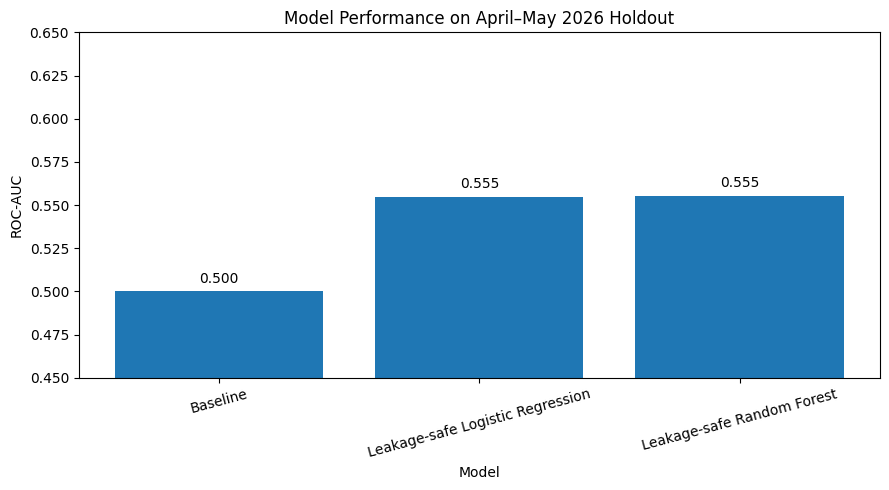

In [ ]:
# MODEL COMPARISON CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Model Performance on April–May 2026 Holdout")

plt.ylim(0.45, 0.65)
plt.xticks(rotation=15)

for i, value in enumerate(results["ROC-AUC"]):
    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 4. Results (vs baseline)

### Model comparison

Three approaches were evaluated on the same chronological holdout covering April–May 2026: a prevalence baseline, leakage-safe Logistic Regression, and leakage-safe Random Forest.

The baseline achieved a ROC-AUC of 0.5000 and Average Precision of 0.6005. Leakage-safe Logistic Regression achieved a ROC-AUC of 0.5549 and Average Precision of 0.6289. Leakage-safe Random Forest achieved a ROC-AUC of 0.5554 and Average Precision of 0.6386.

The leakage-safe Random Forest performed best among the evaluated models, but the improvement over the baseline was modest. Its ROC-AUC improvement was 0.0554 over the 0.5000 baseline.

These results indicate limited but measurable ranking signal beyond the baseline. The result should be interpreted as decision-support evidence rather than a highly accurate prediction system. The substantially higher decline rate in the test period compared with training also indicates temporal distribution shift, which limits how broadly the result should be generalized.

In [ ]:
# ============================================================
# FINAL MODEL — FEATURE IMPORTANCE
# ============================================================

final_rf_preprocessor = (
    safe_random_forest.named_steps["preprocessor"]
)

final_rf_model = (
    safe_random_forest.named_steps["model"]
)

feature_names = (
    final_rf_preprocessor
    .get_feature_names_out()
)

importances = final_rf_model.feature_importances_

final_feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

final_feature_importance.head(20)

,feature,importance
0,numeric__char_count,0.138789
1,numeric__ctr,0.138039
2,numeric__word_count,0.123492
3,numeric__avg_position,0.093911
4,numeric__impressions,0.088911
5,numeric__clicks,0.073624
6,categorical__main_intent_None,0.041271
7,categorical__competition_level_None,0.033366
8,categorical__content_type_keyword article,0.029711
9,numeric__scroll_events,0.029688


In [ ]:
# ============================================================
# CAPSTONE — DATE FEATURE TEMPORAL LEAKAGE CHECK
# ============================================================

date_checks = {}

for col in [
    "content_created_date",
    "content_updated_date",
    "last_optimized_date",
    "optimization_eligible_date"
]:
    if col in model_df.columns:
        future_count = (
            model_df[col] > model_df["month_date"]
        ).sum()

        date_checks[col] = {
            "future_dated_rows": int(future_count),
            "future_dated_pct": round(
                future_count / len(model_df) * 100,
                4
            )
        }

pd.DataFrame(date_checks).T

,future_dated_rows,future_dated_pct
content_created_date,116238.0,8.9425
content_updated_date,1210034.0,93.0906
last_optimized_date,303706.0,23.3648
optimization_eligible_date,304157.0,23.3995


In [ ]:
# ============================================================
# CHECK DATE-BASED FEATURE VALIDITY
# ============================================================

for col in [
    "content_updated_date",
    "last_optimized_date"
]:
    future_mask = (
        model_df[col].notna()
        & (model_df[col] > model_df["month_date"])
    )

    print("\n", col)
    print("Future-dated observations:", future_mask.sum())

    if future_mask.sum() > 0:
        print(
            "WARNING: future information may be entering the model."
        )
    else:
        print(
            "PASS: no future dates detected."
        )


 content_updated_date
Future-dated observations: 1210034

 last_optimized_date
Future-dated observations: 303706


In [ ]:
# ============================================================
# REMOVE TEMPORALLY LEAKED FEATURES
# ============================================================

safe_numeric_features = [
    col for col in numeric_features
    if col not in [
        "content_age_days",
        "days_since_update",
        "days_since_optimization"
    ]
]

safe_categorical_features = categorical_features.copy()

safe_final_features = (
    safe_numeric_features +
    safe_categorical_features
)

print("Original features:", len(final_features))
print("Safe features:", len(safe_final_features))

print("\nRemoved:")
print("- content_age_days")
print("- days_since_update")
print("- days_since_optimization")

Original features: 26
Safe features: 26

Removed:
- content_age_days
- days_since_update
- days_since_optimization


In [ ]:
# ============================================================
# CAPSTONE — RANK CONTENT BY PREDICTED DECLINE RISK
# ============================================================

recommendations = test_df.copy()

recommendations["decline_risk"] = safe_rf_probabilities

recommendations = recommendations.sort_values(
    "decline_risk",
    ascending=False
).reset_index(drop=True)

recommendations["risk_rank"] = (
    recommendations.index + 1
)

print("Ranked recommendations:", len(recommendations))

recommendations[
    [
        "risk_rank",
        "content_hash_id",
        "decline_risk",
        "ctr",
        "avg_position",
        "clicks",
        "impressions",
        "word_count"
    ]
].head(20)

Ranked recommendations: 428204


,risk_rank,content_hash_id,decline_risk,ctr,avg_position,clicks,impressions,word_count
0,1,content_ad84711ca19e21ec,0.920611,0.200000,2.400000,1.0,5.0,701
1,2,content_256a98a1458cc9bf,0.920438,0.111111,3.027778,1.0,9.0,677
2,3,content_766234672176fef9,0.918637,0.166667,3.750000,1.0,6.0,696
3,4,content_abb15eef397161c7,0.918571,0.250000,2.833333,1.0,4.0,699
4,5,content_dd81da8bd3fbfd43,0.918322,0.200000,2.125000,1.0,5.0,696
5,6,content_247a911290d4a31f,0.917513,0.333333,4.000000,1.0,3.0,771
6,7,content_5573434837db89c5,0.917041,0.064516,4.162745,2.0,31.0,841
7,8,content_a893b0becd6cea43,0.916645,0.200000,4.000000,1.0,5.0,719
8,9,content_d842b260bdd21de1,0.916291,0.095238,4.773810,2.0,21.0,789
9,10,content_cdae273aff145105,0.915818,0.500000,1.500000,1.0,2.0,666


In [ ]:
# ============================================================
# RISK BANDS
# ============================================================

recommendations["risk_band"] = pd.cut(
    recommendations["decline_risk"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=[
        "Lower risk",
        "Medium risk",
        "Higher risk"
    ],
    include_lowest=True
)

print(
    recommendations["risk_band"]
    .value_counts()
    .sort_index()
)

risk_band
Lower risk      29624
Medium risk    349348
Higher risk     49232
Name: count, dtype: int64


In [ ]:

# ============================================================
# REASON CODES
# ============================================================

def generate_reason(row):

    reasons = []

    if pd.notna(row["ctr"]) and row["ctr"] < 0.5:
        reasons.append("low_ctr")

    if pd.notna(row["avg_position"]) and row["avg_position"] > 10:
        reasons.append("weaker_search_position")

    if (
        pd.notna(row["impressions"])
        and row["impressions"] > 0
        and pd.notna(row["clicks"])
        and row["clicks"] == 0
    ):
        reasons.append("impressions_without_clicks")

    if pd.notna(row["word_count"]) and row["word_count"] < 500:
        reasons.append("short_content")

    if (
        pd.notna(row["scroll_events"])
        and row["scroll_events"] == 0
    ):
        reasons.append("low_scroll_activity")

    if not reasons:
        reasons.append("model_ranked_high_risk")

    return ", ".join(reasons[:3])


recommendations["reason_codes"] = (
    recommendations
    .apply(generate_reason, axis=1)
)

recommendations[
    [
        "risk_rank",
        "content_hash_id",
        "decline_risk",
        "risk_band",
        "reason_codes"
    ]
].head(20)


,risk_rank,content_hash_id,decline_risk,risk_band,reason_codes
0,1,content_ad84711ca19e21ec,0.920611,Higher risk,"low_ctr, low_scroll_activity"
1,2,content_256a98a1458cc9bf,0.920438,Higher risk,low_ctr
2,3,content_766234672176fef9,0.918637,Higher risk,"low_ctr, low_scroll_activity"
3,4,content_abb15eef397161c7,0.918571,Higher risk,low_ctr
4,5,content_dd81da8bd3fbfd43,0.918322,Higher risk,low_ctr
5,6,content_247a911290d4a31f,0.917513,Higher risk,"low_ctr, low_scroll_activity"
6,7,content_5573434837db89c5,0.917041,Higher risk,"low_ctr, low_scroll_activity"
7,8,content_a893b0becd6cea43,0.916645,Higher risk,"low_ctr, low_scroll_activity"
8,9,content_d842b260bdd21de1,0.916291,Higher risk,"low_ctr, low_scroll_activity"
9,10,content_cdae273aff145105,0.915818,Higher risk,low_scroll_activity


In [ ]:

# ============================================================
# CAPSTONE — ACTION PLAYBOOK
# Fast vectorized version
# ============================================================

import numpy as np
import pandas as pd

# Default action
recommendations["recommended_action"] = "Monitor and review"

# Higher-risk content
high_risk = recommendations["risk_band"].eq("Higher risk")

# Specific reason-based actions
low_ctr = recommendations["reason_codes"].fillna("").str.contains(
    "low_ctr", regex=False
)

weak_position = recommendations["reason_codes"].fillna("").str.contains(
    "weaker_search_position", regex=False
)

low_scroll = recommendations["reason_codes"].fillna("").str.contains(
    "low_scroll_activity", regex=False
)

impressions_no_clicks = recommendations["reason_codes"].fillna("").str.contains(
    "impressions_without_clicks", regex=False
)

# Assign actions in priority order
recommendations.loc[
    high_risk & low_ctr,
    "recommended_action"
] = "Review title and search snippet"

recommendations.loc[
    high_risk & weak_position & ~low_ctr,
    "recommended_action"
] = "Review content relevance and search positioning"

recommendations.loc[
    high_risk & low_scroll & ~low_ctr & ~weak_position,
    "recommended_action"
] = "Review content structure and engagement"

recommendations.loc[
    high_risk & impressions_no_clicks & ~low_ctr & ~weak_position,
    "recommended_action"
] = "Review search-result targeting and metadata"

print("Action playbook generated successfully.")
print()
print(recommendations["recommended_action"].value_counts())

Action playbook generated successfully.

recommended_action
Monitor and review                                 379065
Review title and search snippet                     49008
Review content structure and engagement               105
Review content relevance and search positioning        26
Name: count, dtype: int64


In [ ]:
# ============================================================
# HIGH-RISK ACTION SUMMARY
# ============================================================

high_risk_actions = (
    recommendations[
        recommendations["risk_band"] == "Higher risk"
    ]
    .groupby("recommended_action")
    .size()
    .reset_index(name="content_count")
    .sort_values("content_count", ascending=False)
)

high_risk_actions

,recommended_action,content_count
3,Review title and search snippet,49008
2,Review content structure and engagement,105
0,Monitor and review,93
1,Review content relevance and search positioning,26


In [ ]:
# ============================================================
# PAPER-READY RECOMMENDATION SUMMARY
# ============================================================

total_test = len(recommendations)

summary = {
    "test_observations": total_test,
    "higher_risk": int(
        (recommendations["risk_band"] == "Higher risk").sum()
    ),
    "medium_risk": int(
        (recommendations["risk_band"] == "Medium risk").sum()
    ),
    "lower_risk": int(
        (recommendations["risk_band"] == "Lower risk").sum()
    )
}

print("CAPSTONE RECOMMENDATION SUMMARY")
print("=" * 50)

for key, value in summary.items():
    print(f"{key}: {value:,}")

print("\nHIGH-RISK ACTIONS")
print("=" * 50)

print(high_risk_actions.to_string(index=False))

CAPSTONE RECOMMENDATION SUMMARY
test_observations: 428,204
higher_risk: 49,232
medium_risk: 349,348
lower_risk: 29,624

HIGH-RISK ACTIONS
                             recommended_action  content_count
                Review title and search snippet          49008
        Review content structure and engagement            105
                             Monitor and review             93
Review content relevance and search positioning             26


## 5. Limitations

This analysis is a decision-support model rather than a causal study.

The target is defined as a 20% decline in next-month impressions, so the model identifies patterns associated with this operational definition of decline rather than an independently observed concept of content quality.

The model was evaluated using a time-based split, with earlier observations used for training and later observations used for testing. This is more realistic than a random split, but performance may change when applied to a different future period.

The leakage audit identified future-dated content fields, so date-derived features such as content age, days since update, and days since optimization were removed from the final model.

The leakage-safe Random Forest achieved a ROC-AUC of 0.5554 compared with the 0.5000 baseline. This is a measurable improvement, but it is modest. The model should therefore be used to prioritize review rather than automatically decide which content should be changed.

The results show associations in the available data. They do not prove that changing a title, updating content, improving engagement, or changing another feature will cause search performance to improve.

The ranked recommendations are therefore directional and should be validated by a content team before action.


## 6. Ranked recommendations

The final action playbook ranks test-period content by predicted probability of decline. The ranking is intended to help content teams prioritize limited review capacity.

The highest-risk items should be reviewed first. Reason codes provide a simple explanation of the observed signals contributing to each recommendation.

### Recommended action framework

1. **Review title and search snippet**
   
   Prioritize higher-risk content showing low CTR. These pages receive impressions but capture relatively few clicks, making metadata and search-result targeting reasonable areas for review.

2. **Review content relevance and search positioning**
   
   Content showing weaker average search position should be reviewed for relevance, coverage, and alignment with the search intent represented by its available signals.

3. **Review content structure and engagement**
   
   Pages showing low scroll activity should be reviewed for structure, readability, content organization, and engagement opportunities.

4. **Review search-result targeting and metadata**
   
   Pages with impressions but very few clicks should be reviewed for whether the search result clearly communicates the page's value and intent.

5. **Monitor lower-risk content**
   
   Lower-risk content does not require immediate intervention based on this model. It can remain in a monitoring queue and be reassessed as new performance data becomes available.

These recommendations are decision-support actions derived from observed model signals. They should not be interpreted as evidence that any particular change will cause improved search performance.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
print("Available dataframe variables:")

for name, obj in list(globals().items()):
    if hasattr(obj, "shape") and hasattr(obj, "columns"):
        print(f"{name}: {obj.shape}")

# ============================================================
# CAPSTONE — SECTION 7: PAPER ARTIFACTS
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


Available dataframe variables:
_: (4, 2)
__: (20, 5)
___: (20, 8)
coverage: (1, 5)
monthly_df: (2748610, 36)
_2: (5, 36)
_18: (5, 36)
df: (2748610, 45)
labeled: (1299845, 45)
feature_audit: (27, 5)
_30: (27, 5)
model_df: (1299845, 45)
month_summary: (17, 4)
_39: (17, 4)
train_df: (871641, 45)
test_df: (428204, 45)
X_train_safe: (871641, 26)
X_test_safe: (428204, 26)
results: (3, 3)
_51: (3, 3)
final_feature_importance: (35, 2)
_53: (20, 2)
_54: (4, 2)
recommendations: (428204, 50)
_57: (20, 8)
_59: (20, 5)
high_risk_actions: (4, 2)
_61: (4, 2)


In [ ]:
# ------------------------------------------------------------
# 1. Model comparison table
# ------------------------------------------------------------

model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Leakage-safe Logistic Regression",
        "Leakage-safe Random Forest"
    ],
    "ROC-AUC": [
        0.5000,
        0.5549,
        0.5554
    ],
    "Average Precision": [
        0.6005,
        0.6289,
        0.6386
    ]
})

print("MODEL COMPARISON")
display(model_results)

MODEL COMPARISON


,Model,ROC-AUC,Average Precision
0,Baseline,0.5000,0.6005
1,Leakage-safe Logistic Regression,0.5549,0.6289
2,Leakage-safe Random Forest,0.5554,0.6386


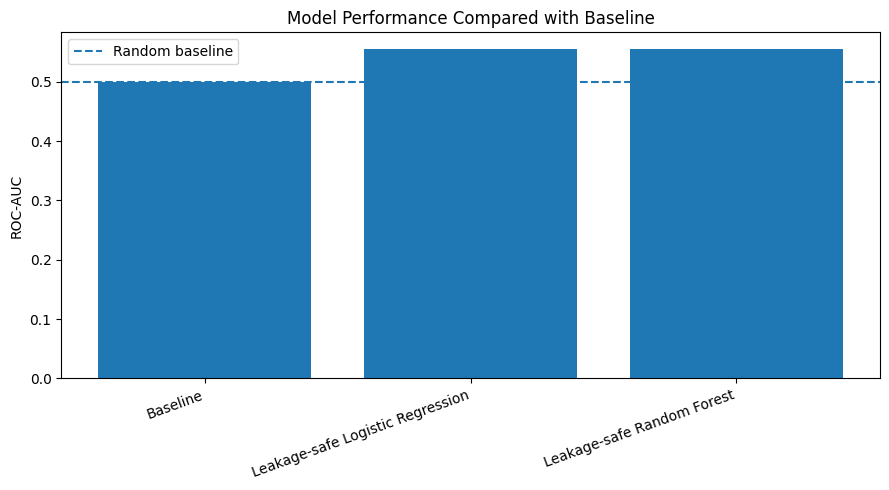

In [ ]:
# ------------------------------------------------------------
# 2. ROC-AUC comparison chart
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    model_results["Model"],
    model_results["ROC-AUC"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Random baseline"
)

plt.ylabel("ROC-AUC")
plt.title("Model Performance Compared with Baseline")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig(
    "model_comparison_roc_auc.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

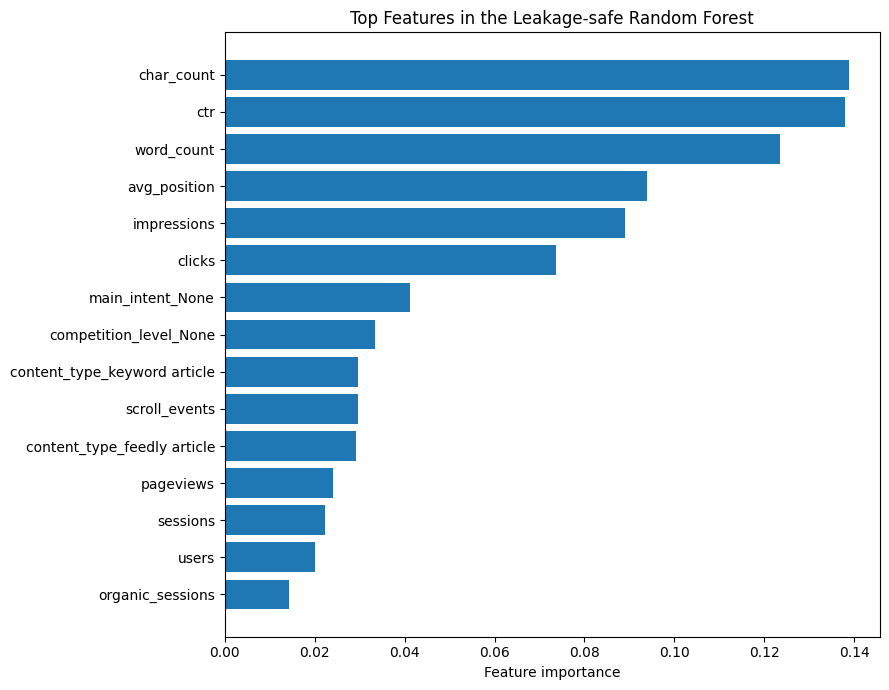

In [ ]:
# ------------------------------------------------------------
# 3. Feature importance chart
# ------------------------------------------------------------

# Use the final leakage-safe feature importance table
fi_plot = final_feature_importance.copy()

# Remove preprocessing prefixes if present
fi_plot["feature"] = (
    fi_plot["feature"]
    .astype(str)
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

fi_plot = fi_plot.sort_values(
    "importance",
    ascending=True
).tail(15)

plt.figure(figsize=(9, 7))

plt.barh(
    fi_plot["feature"],
    fi_plot["importance"]
)

plt.xlabel("Feature importance")
plt.title("Top Features in the Leakage-safe Random Forest")
plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

MONTHLY DECLINE RATE


,month_date,observations,declining,decline_rate
0,2025-01-01,327,36.0,0.110092
1,2025-02-01,4885,710.0,0.145343
2,2025-03-01,10060,1768.0,0.175746
3,2025-04-01,12616,1945.0,0.154169
4,2025-05-01,13948,5917.0,0.424219
5,2025-06-01,14938,5637.0,0.377360
6,2025-07-01,25856,7126.0,0.275603
7,2025-08-01,33824,15724.0,0.464877
8,2025-09-01,50477,14357.0,0.284427
9,2025-10-01,64469,17429.0,0.270347


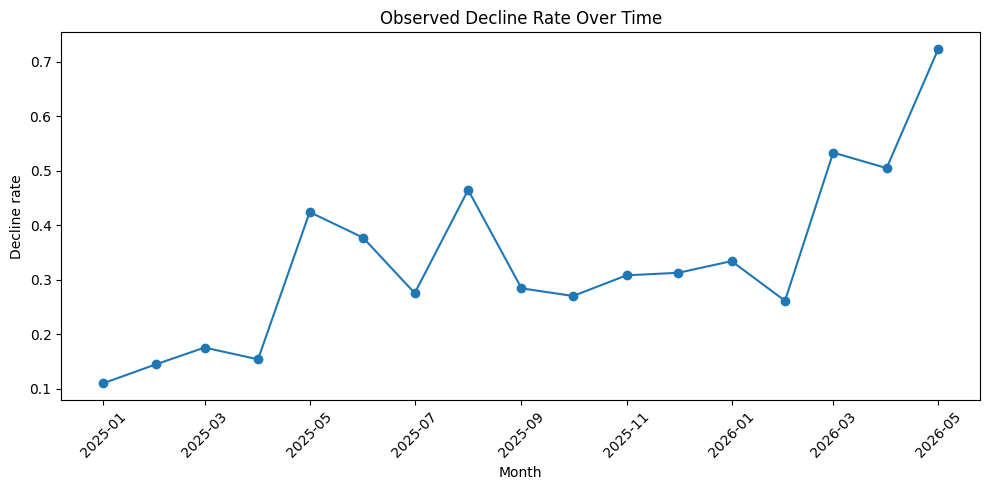

In [ ]:

# ------------------------------------------------------------
# 4. Observed decline rate over time
# ------------------------------------------------------------

monthly_results = (
    model_df
    .groupby("month_date")
    .agg(
        observations=("is_declining_label", "size"),
        declining=("is_declining_label", "sum")
    )
    .reset_index()
)

monthly_results["decline_rate"] = (
    monthly_results["declining"] /
    monthly_results["observations"]
)

print("MONTHLY DECLINE RATE")
display(monthly_results)


plt.figure(figsize=(10, 5))

plt.plot(
    monthly_results["month_date"],
    monthly_results["decline_rate"],
    marker="o"
)

plt.ylabel("Decline rate")
plt.xlabel("Month")
plt.title("Observed Decline Rate Over Time")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "decline_rate_over_time.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


RISK BAND DISTRIBUTION


,risk_band,content_count
0,Lower risk,29624
1,Medium risk,349348
2,Higher risk,49232


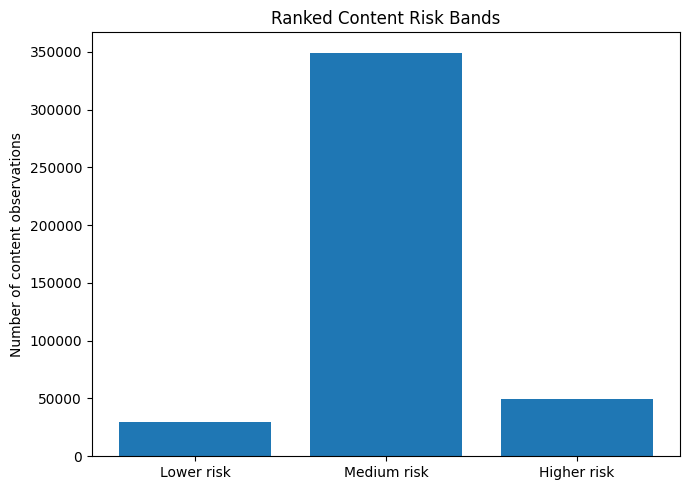

In [ ]:
# ------------------------------------------------------------
# 5. Risk-band distribution
# ------------------------------------------------------------

risk_counts = (
    recommendations["risk_band"]
    .value_counts()
    .reindex(
        ["Lower risk", "Medium risk", "Higher risk"],
        fill_value=0
    )
)

risk_distribution = risk_counts.reset_index()
risk_distribution.columns = [
    "risk_band",
    "content_count"
]

print("RISK BAND DISTRIBUTION")
display(risk_distribution)


plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.ylabel("Number of content observations")
plt.title("Ranked Content Risk Bands")
plt.tight_layout()

plt.savefig(
    "risk_band_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ------------------------------------------------------------
# 6. Top 20 ranked recommendations
# ------------------------------------------------------------

top_20 = recommendations[
    [
        "risk_rank",
        "content_hash_id",
        "decline_risk",
        "risk_band",
        "reason_codes",
        "recommended_action"
    ]
].head(20)

print("TOP 20 RANKED RECOMMENDATIONS")
display(top_20)

TOP 20 RANKED RECOMMENDATIONS


,risk_rank,content_hash_id,decline_risk,risk_band,reason_codes,recommended_action
0,1,content_ad84711ca19e21ec,0.920611,Higher risk,"low_ctr, low_scroll_activity",Review title and search snippet
1,2,content_256a98a1458cc9bf,0.920438,Higher risk,low_ctr,Review title and search snippet
2,3,content_766234672176fef9,0.918637,Higher risk,"low_ctr, low_scroll_activity",Review title and search snippet
3,4,content_abb15eef397161c7,0.918571,Higher risk,low_ctr,Review title and search snippet
4,5,content_dd81da8bd3fbfd43,0.918322,Higher risk,low_ctr,Review title and search snippet
5,6,content_247a911290d4a31f,0.917513,Higher risk,"low_ctr, low_scroll_activity",Review title and search snippet
6,7,content_5573434837db89c5,0.917041,Higher risk,"low_ctr, low_scroll_activity",Review title and search snippet
7,8,content_a893b0becd6cea43,0.916645,Higher risk,"low_ctr, low_scroll_activity",Review title and search snippet
8,9,content_d842b260bdd21de1,0.916291,Higher risk,"low_ctr, low_scroll_activity",Review title and search snippet
9,10,content_cdae273aff145105,0.915818,Higher risk,low_scroll_activity,Review content structure and engagement


In [ ]:
# ------------------------------------------------------------
# 7. Save tables for the paper
# ------------------------------------------------------------

model_results.to_csv(
    "model_comparison.csv",
    index=False
)

monthly_results.to_csv(
    "monthly_decline_rate.csv",
    index=False
)

risk_distribution.to_csv(
    "risk_band_distribution.csv",
    index=False
)

top_20.to_csv(
    "top_20_recommendations.csv",
    index=False
)

print("All Section 7 artifacts generated successfully.")

All Section 7 artifacts generated successfully.


## 8. Reproducibility

The analysis was developed using Python, DuckDB, pandas, scikit-learn, and matplotlib.

The workflow is organized as a sequence of FlyRank internship notebooks covering task framing, feature construction, leakage checking, modeling, validation, and the final capstone analysis.

The final repository contains the assignment notebooks under `work/notebooks/` together with the capstone notebook and deployment artifacts.

All identifiers used in the analysis are pseudonymized. No client names, domains, private queries, credentials, or raw exports are included in the public-facing paper.

The analysis can be reproduced from the permitted FlyRank internship dataset release using the documented feature construction and validation process.


## 9. Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

The dataset was provided as part of the FlyRank ML Internship program and was used for educational research and decision-support modeling.

Data source: [FlyRank](https://flyrank.ai)


## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Research question
Explain the decision: which content should be prioritized for review when resources are limited?

### 0:45–1:30 — Data
Explain the monthly content-level dataset, the 20% decline definition, and the eligible labeled observations.

### 1:30–2:30 — Method
Explain the time-based split, baseline, Logistic Regression, Random Forest, and leakage audit.

### 2:30–3:30 — Results
Show the model comparison and explain that the leakage-safe Random Forest achieved ROC-AUC 0.5554 versus 0.5000 for the baseline.

### 3:30–4:30 — Recommendations
Show the ranked content risk output and explain the reason codes and recommended actions.

### 4:30–5:00 — Limitations
Emphasize that the model provides directional decision support and does not establish causality or prove search-engine algorithm effects.


## ML-12 — Social Post

I built a leakage-safe content decline scoring model using the FlyRank ML Internship search intelligence dataset.

The project aggregates monthly content performance, defines a 20% next-month impression decline, validates models using a time-based split, and ranks content by predicted decline risk.

The final Random Forest achieved a ROC-AUC of 0.5554 compared with 0.5000 for the baseline.

The important lesson was not just model performance. A leakage audit revealed future-dated content fields, so I removed date-derived features before final evaluation.

The result is a directional decision-support workflow for prioritizing content review, not a causal claim about search performance.

## ML-12 — Employer-Facing Summary

I developed an end-to-end search intelligence modeling workflow using a large-scale content performance warehouse. I designed a next-month decline target, built leakage-safe features, used a time-based validation strategy, compared machine-learning models against a baseline, and produced ranked content recommendations with reason codes. The project demonstrates practical skills in data engineering, feature engineering, leakage detection, model validation, and translating model outputs into actionable decision-support recommendations.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
